Group 35 Data 102 Final Project: Natalie Cornejo, Neha Keagy, Lauren Angelus, Jerry Ho

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [ ]:
rep_candidates = pd.read_csv("rep_candidates.csv")
rep_candidates

,Candidate,Gender,Race 1,Race 2,Race 3,Incumbent,Incumbent Challenger,State,Primary Date,Office,...,2020 Election Stance,Trump,Trump Date,Club for Growth,Party Committee,Renew America,E-PAC,VIEW PAC,Maggie's List,Winning for Women
0,"Aditya ""A.D."" Atholi",Male,Asian (Indian),NaN,NaN,No,No,Texas,3/1/22,Representative,...,No comment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Joe McDaniel,Male,White,NaN,NaN,No,No,Texas,3/1/22,Representative,...,Raised questions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Nathaniel Moran,Male,White,NaN,NaN,No,No,Texas,3/1/22,Representative,...,Raised questions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,John Porro,Male,White,NaN,NaN,No,No,Texas,3/1/22,Representative,...,No comment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dan Crenshaw,Male,White,NaN,NaN,Yes,No,Texas,3/1/22,Representative,...,Accepted with reservations,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,Karen Testerman,Female,Asian (Japanese),White,NaN,No,Yes,New Hampshire,9/13/22,Governor,...,Fully denied,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
1595,Allen R. Waters,Male,Black,NaN,NaN,No,No,Rhode Island,9/13/22,Representative,...,No comment,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
1596,Allan W. Fung,Male,Asian (Chinese),NaN,NaN,No,No,Rhode Island,9/13/22,Representative,...,Accepted with reservations,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN
1597,Ashley Marie Kalus,Female,White,NaN,NaN,No,No,Rhode Island,9/13/22,Governor,...,Avoided answering,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Research Question #1:

In 2022 primary elections, is there a causal effect of receiving an endorsement from Donald Trump on a candidate’s chance of winning?

**EDA**

Visualization 1: Relationship between Trump Endorsements & vote share
-

(for their chance of winning in the elections) Categorical-Quantitative Plot



In [ ]:
# first need to clean data because there are lots of NaN values in the 'Trump' column & make it to a binary 0/1 for easier reference

def clean_trump_col(value):
    if pd.isna(value):
        return 0  # No endorsement recorded
    value = str(value).lower()
    if "yes" in value:
        return 1
    else:
        return 0

rep_candidates["trump_endorsed"] = rep_candidates["Trump"].apply(clean_trump_col)
rep_candidates["trump_endorsed"].value_counts()


,count
trump_endorsed,
0,1409
1,190


In [ ]:
#more cleaning
rep_candidates["Primary %"] = rep_candidates["Primary %"].astype(str)

#remove percent signs
rep_candidates["Primary %"] = rep_candidates["Primary %"].str.replace("%", "", regex=False)

# remove commas
rep_candidates["Primary %"] = rep_candidates["Primary %"].str.replace(",", "", regex=False)

# digits only (removes weird symbols)
rep_candidates["Primary %"] = rep_candidates["Primary %"].str.extract(r'(\d+\.?\d*)')

# convert to float
rep_candidates["Primary %"] = pd.to_numeric(rep_candidates["Primary %"], errors="coerce")

#bins so its easier to visualize
rep_candidates["share_bin"] = pd.cut(
    rep_candidates["Primary %"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=["0–10%", "10–20%", "20–30%", "30–40%", "40–50%",
            "50–60%", "60–70%", "70–80%", "80–90%", "90–100%"]
)

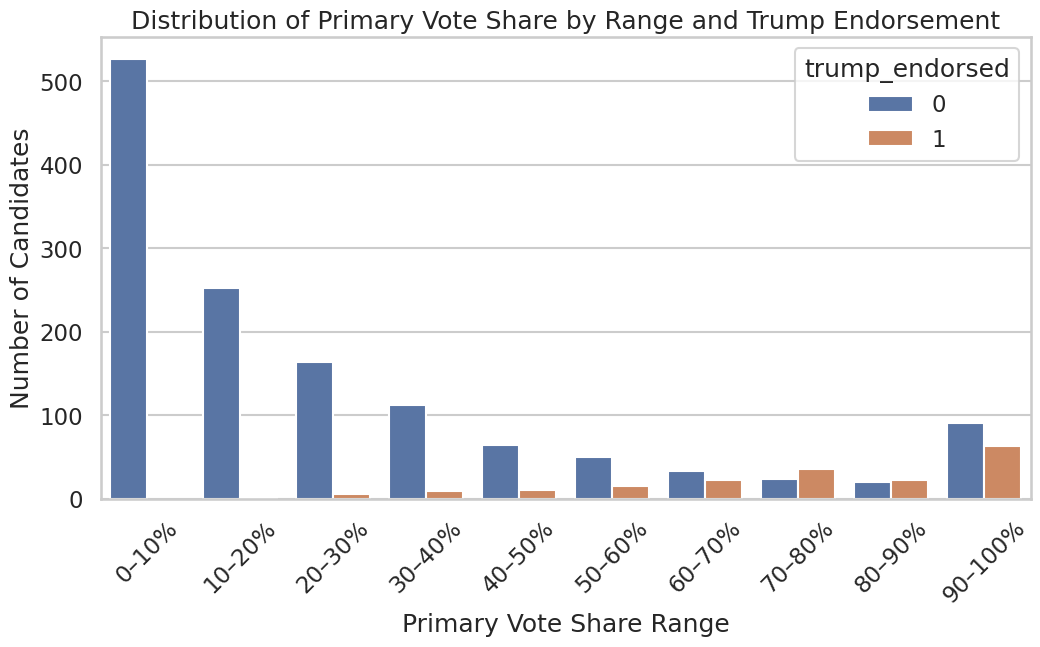

In [ ]:
#now on to the actual visualization
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12,6))
sns.countplot(
    data=rep_candidates,
    x="share_bin",
    hue="trump_endorsed"
)

plt.xticks(rotation=45)
plt.xlabel("Primary Vote Share Range")
plt.ylabel("Number of Candidates")
plt.title("Distribution of Primary Vote Share by Range and Trump Endorsement")
plt.show()



Quantitative visual 2
-

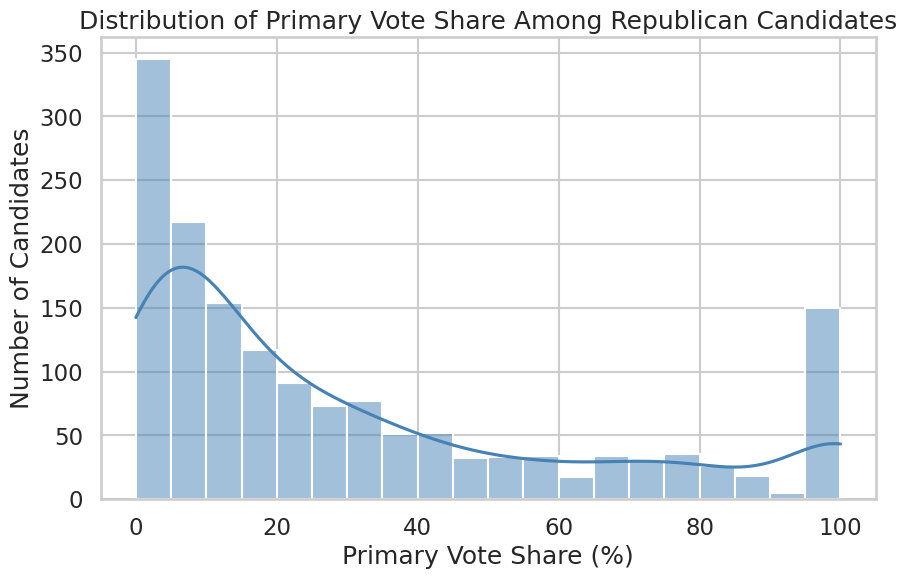

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(
    rep_candidates["Primary %"],
    bins=20,
    color="steelblue",
    kde=True
)

plt.xlabel("Primary Vote Share (%)")
plt.ylabel("Number of Candidates")
plt.title("Distribution of Primary Vote Share Among Republican Candidates")
plt.show()

RQ #1 Methods
-

In [ ]:
# we first need to use IPW to ensure randomness

'''first we find the propensity score.
One way to quantify the degree of confounding is using the conditional probability of receving the treatment
given the confounder: this is called the propensity score. '''

df_rq1 = rep_candidates.copy()

# 1. Treatment and outcome as 0/1
df_rq1["trump_endorsed"] = (df_rq1["Trump"] == "Yes").astype(int)
df_rq1["won_primary"] = df_rq1["Primary Outcome"].str.contains("won", case=False, na=False).astype(int)

# 2. Confounders
df_rq1["is_incumbent"] = (df_rq1["Incumbent"] == "Yes").astype(int)
df_rq1["is_female"] = (df_rq1["Gender"] == "Female").astype(int)

# White vs non-white (race confounder)
df_rq1["is_white"] = (df_rq1["Race 1"] == "White").astype(int)

# Region/state
df_rq1["Region"] = df_rq1["State"]

# Fundraising: PAC money
# PAC / other endorsements in the dataset
pac_cols = [
    "Club for Growth",
    "Party Committee",
    "Renew America",
    "E-PAC",
    "VIEW PAC",
    "Maggie's List",
    "Winning for Women",
]
df_rq1["has_pac_endorse"] = (df_rq1[pac_cols] == "Yes").any(axis=1).astype(int)

confounder_cols = [
    "is_incumbent","is_female","is_white","Region","has_pac_endorse"]
df_rq1 = df_rq1.dropna(subset=["trump_endorsed", "won_primary"] + confounder_cols)

df_rq1

,Candidate,Gender,Race 1,Race 2,Race 3,Incumbent,Incumbent Challenger,State,Primary Date,Office,...,Maggie's List,Winning for Women,trump_endorsed,share_bin,won_primary,is_incumbent,is_female,is_white,Region,has_pac_endorse
0,"Aditya ""A.D."" Atholi",Male,Asian (Indian),NaN,NaN,No,No,Texas,3/1/22,Representative,...,NaN,NaN,0,0–10%,0,0,0,0,Texas,0
1,Joe McDaniel,Male,White,NaN,NaN,No,No,Texas,3/1/22,Representative,...,NaN,NaN,0,20–30%,0,0,0,1,Texas,0
2,Nathaniel Moran,Male,White,NaN,NaN,No,No,Texas,3/1/22,Representative,...,NaN,NaN,0,60–70%,1,0,0,1,Texas,0
3,John Porro,Male,White,NaN,NaN,No,No,Texas,3/1/22,Representative,...,NaN,NaN,0,0–10%,0,0,0,1,Texas,0
4,Dan Crenshaw,Male,White,NaN,NaN,Yes,No,Texas,3/1/22,Representative,...,NaN,NaN,0,70–80%,1,1,0,1,Texas,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,Karen Testerman,Female,Asian (Japanese),White,NaN,No,Yes,New Hampshire,9/13/22,Governor,...,NaN,NaN,0,0–10%,0,0,1,0,New Hampshire,0
1595,Allen R. Waters,Male,Black,NaN,NaN,No,No,Rhode Island,9/13/22,Representative,...,NaN,NaN,0,90–100%,1,0,0,0,Rhode Island,0
1596,Allan W. Fung,Male,Asian (Chinese),NaN,NaN,No,No,Rhode Island,9/13/22,Representative,...,NaN,NaN,0,90–100%,1,0,0,0,Rhode Island,1
1597,Ashley Marie Kalus,Female,White,NaN,NaN,No,No,Rhode Island,9/13/22,Governor,...,NaN,NaN,0,80–90%,1,0,1,1,Rhode Island,0


In [ ]:
#MAKE SURE TO ONLY RUN THIS ONCE AFTER RUNNING THE CELL FROM ABOVE OR WE GET DUPLICATE PROPENSITY SCORES

# group-based propensity scores
df_rq1 = df_rq1.drop(columns=["propensity_score"], errors="ignore")

group_means = (
    df_rq1.groupby(confounder_cols)["trump_endorsed"]
      .mean()
      .reset_index(name="propensity_score")
)

df_rq1 = df_rq1.merge(group_means, on=confounder_cols, how="left", validate="m:1")



In [ ]:
#making sure the propensity scores are not all 0
df_rq1[df_rq1['propensity_score']!= 0]

,Candidate,Gender,Race 1,Race 2,Race 3,Incumbent,Incumbent Challenger,State,Primary Date,Office,...,Winning for Women,trump_endorsed,share_bin,won_primary,is_incumbent,is_female,is_white,Region,has_pac_endorse,propensity_score
4,Dan Crenshaw,Male,White,NaN,NaN,Yes,No,Texas,3/1/22,Representative,...,NaN,0,70–80%,1,1,0,1,Texas,0,0.823529
11,Van Taylor,Male,White,NaN,NaN,Yes,No,Texas,3/1/22,Representative,...,NaN,0,40–50%,0,1,0,1,Texas,0,0.823529
13,Pat Fallon,Male,White,NaN,NaN,Yes,No,Texas,3/1/22,Representative,...,NaN,1,50–60%,1,1,0,1,Texas,0,0.823529
16,Lance Gooden,Male,White,NaN,NaN,Yes,No,Texas,3/1/22,Representative,...,NaN,1,90–100%,1,1,0,1,Texas,0,0.823529
18,Jake Ellzey,Male,White,NaN,NaN,Yes,No,Texas,3/1/22,Representative,...,NaN,1,70–80%,1,1,0,1,Texas,0,0.823529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1554,Robert G. Burke,Male,White,NaN,NaN,No,No,Massachusetts,9/6/22,Representative,...,NaN,0,70–80%,1,0,0,1,Massachusetts,0,0.125000
1556,Jesse G. Brown,Male,White,NaN,NaN,No,No,Massachusetts,9/6/22,Representative,...,NaN,0,50–60%,1,0,0,1,Massachusetts,0,0.125000
1557,Dan Sullivan,Male,White,NaN,NaN,No,No,Massachusetts,9/6/22,Representative,...,NaN,0,40–50%,0,0,0,1,Massachusetts,0,0.125000
1558,Geoff Diehl,Male,White,NaN,NaN,No,No,Massachusetts,9/6/22,Governor,...,NaN,1,50–60%,1,0,0,1,Massachusetts,0,0.125000


In [ ]:
#need to trim any extreme propensity scores or else the weighing estimators can blow up to infinity which proves to be unstable
#therefore we trim any extreme values to stablize the IPW, but creates some additional arbitrariness into the process.
df_rq1["propensity_clipped"] = df_rq1["propensity_score"].clip(0.05, 0.95)

# 2. Compute inverse propensity weights
df_rq1["ipw_weight"] = np.where(
    df_rq1["trump_endorsed"] == 1,
    1.0 / df_rq1["propensity_clipped"],           # treated: 1 / e(X)
    1.0 / (1.0 - df_rq1["propensity_clipped"])    # control: 1 / (1 - e(X))
)
treated  = df_rq1["trump_endorsed"] == 1
control  = df_rq1["trump_endorsed"] == 0


mu1 = (df_rq1.loc[treated, "won_primary"] * df_rq1.loc[treated, "ipw_weight"]).sum() / df_rq1.loc[treated, "ipw_weight"].sum()
mu0 = (df_rq1.loc[control, "won_primary"] * df_rq1.loc[control, "ipw_weight"]).sum() / df_rq1.loc[control, "ipw_weight"].sum()

ate_ipw = mu1 - mu0
print("IPW ATE (Trump endorsement on win prob):", ate_ipw)

IPW ATE (Trump endorsement on win prob): 0.5882999517089282


In [ ]:
Y = df_rq1["won_primary"]
X = sm.add_constant(df_rq1["trump_endorsed"])

# weighted logistic regression (Binomial GLM with frequency weights)
logit_ipw = sm.GLM(
    Y,
    X,
    family=sm.families.Binomial(),
    freq_weights=df_rq1["ipw_weight"]
).fit()

print(logit_ipw.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            won_primary   No. Observations:                 1599
Model:                            GLM   Df Residuals:                     2080
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1093.7
Date:                Wed, 17 Dec 2025   Deviance:                       2187.5
Time:                        04:13:01   Pearson chi2:                 2.08e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3025
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.1852      0.060    -19.

# Research Question #2:

In 2022 primary elections, are there significant differences in primary win rates across various candidate demographic/positional groups (including gender, race, endorsement, current candidate position, finances, etc)? If so, which differences are statistically significant after multiple comparisons?

**EDA**

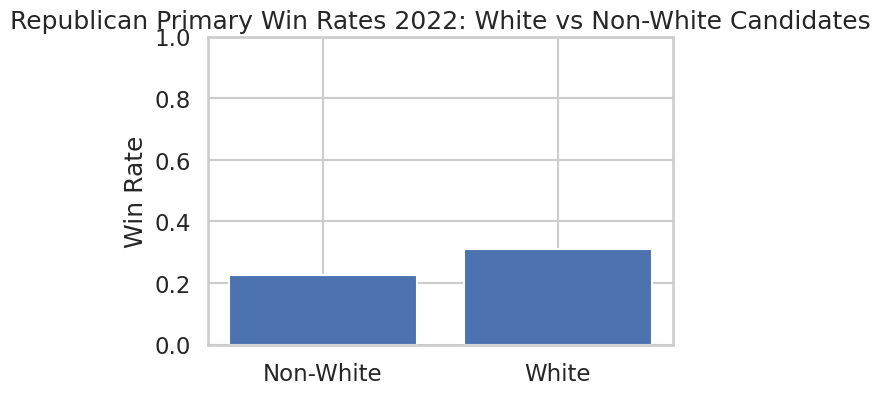

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

##impact of race on Republican primary elections
df = pd.read_csv("rep_candidates.csv")
df["is_white"] = df[["Race 1", "Race 2", "Race 3"]].eq("White").any(axis=1)
df["won_primary"] = df["Primary Outcome"] == "Won"
win_rates = df.groupby("is_white")["won_primary"].mean().reset_index()
win_rates["Race Group"] = win_rates["is_white"].map({True:"White", False:"Non-White"})
plt.figure(figsize=(6,4))
plt.ylim(0,1)
plt.bar(win_rates["Race Group"], win_rates["won_primary"])
plt.ylabel("Win Rate")
plt.title("Republican Primary Win Rates 2022: White vs Non-White Candidates")

plt.show()

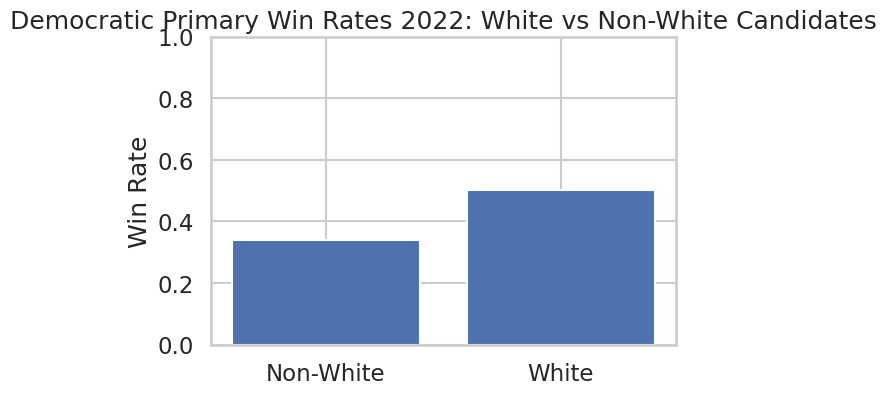

In [ ]:
##impact of race on Democratic party elections
df = pd.read_csv("dem_candidates.csv")
df["is_white"] = df[["Race 1", "Race 2", "Race 3"]].eq("White").any(axis=1)
df["won_primary"] = df["Primary Outcome"] == "Won"
win_rates = df.groupby("is_white")["won_primary"].mean().reset_index()
win_rates["Race Group"] = win_rates["is_white"].map({True:"White", False:"Non-White"})
plt.figure(figsize=(6,4))
plt.ylim(0,1)
plt.bar(win_rates["Race Group"], win_rates["won_primary"])
plt.ylabel("Win Rate")
plt.title("Democratic Primary Win Rates 2022: White vs Non-White Candidates")
plt.show()

/tmp/ipython-input-4005839824.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dem["Primary Date"] = pd.to_datetime(dem["Primary Date"], errors="coerce")


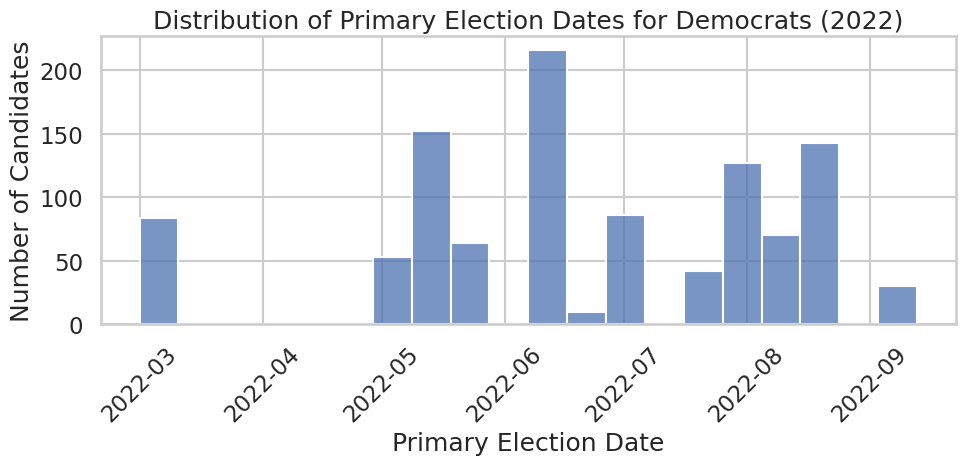

In [ ]:
# Load Democratic candidate data
dem = pd.read_csv("dem_candidates.csv")
dem["Primary Date"] = pd.to_datetime(dem["Primary Date"], errors="coerce")
clean_dates_dem = dem.dropna(subset=["Primary Date"])
plt.figure(figsize=(10,5))
sns.histplot(clean_dates_dem["Primary Date"], bins=20)
plt.xlabel("Primary Election Date")
plt.ylabel("Number of Candidates")
plt.title("Distribution of Primary Election Dates for Democrats (2022)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-389603329.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rep["Primary Date"] = pd.to_datetime(rep["Primary Date"], errors="coerce")


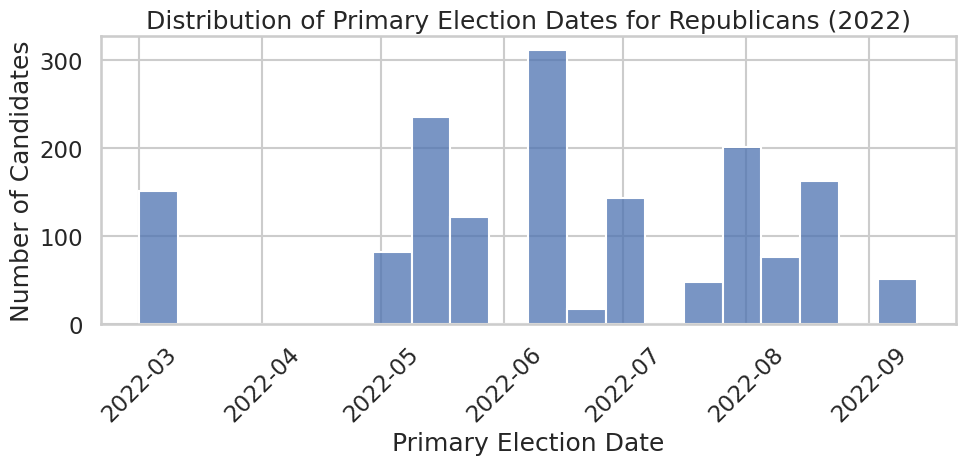

In [ ]:
# Load Democratic candidate data
rep = pd.read_csv("rep_candidates.csv")
rep["Primary Date"] = pd.to_datetime(rep["Primary Date"], errors="coerce")
clean_dates_rep = rep.dropna(subset=["Primary Date"])
plt.figure(figsize=(10,5))
sns.histplot(clean_dates_rep["Primary Date"], bins=20)
plt.xlabel("Primary Election Date")
plt.ylabel("Number of Candidates")
plt.title("Distribution of Primary Election Dates for Republicans (2022)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

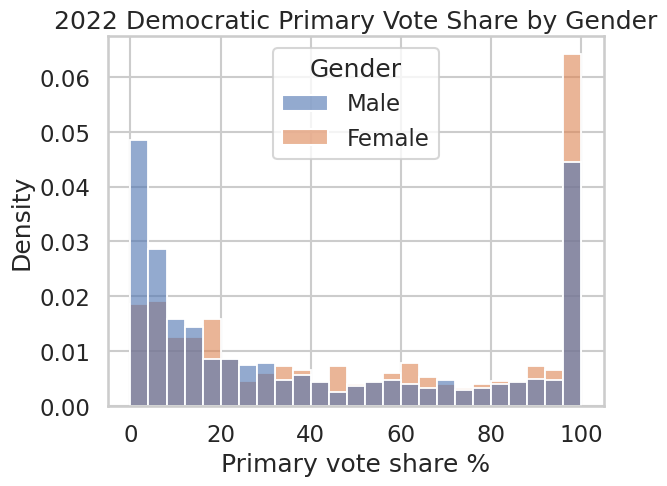

In [ ]:
##democrat histogram by gender
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
dem = pd.read_csv("dem_candidates.csv")
democ = dem[dem["Primary %"].notna() & dem["Gender"].notna()].copy()
democ = democ[democ["Gender"].isin(["Male", "Female"])]
democ["Primary_cleaned"] = democ["Primary %"].astype(str).str.replace("%", "")
democ["vote_share"] = pd.to_numeric(democ["Primary_cleaned"], errors = "coerce")
sns.histplot(
 data = democ,
 x = "vote_share",
 hue = "Gender",
 bins = 25,
 stat = "density",
 common_norm = False,
 alpha = 0.6)
plt.title("2022 Democratic Primary Vote Share by Gender")
plt.xlabel("Primary vote share %")
plt.show()

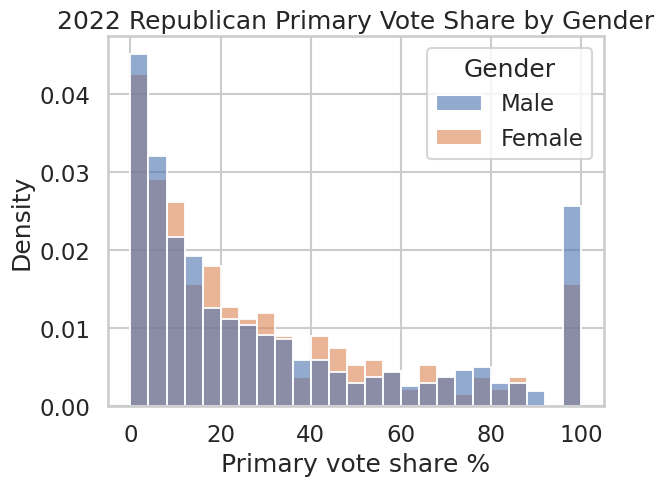

In [ ]:
##republican histogram by gender
rep = pd.read_csv("rep_candidates.csv")
repub = rep[rep["Primary %"].notna() & rep["Gender"].notna()].copy()
repub = repub[repub["Gender"].isin(["Male", "Female"])]
repub["Primary_cleaned"] = repub["Primary %"].astype(str).str.replace("%", "")
repub["vote_share"] = pd.to_numeric(repub["Primary_cleaned"], errors = "coerce")
sns.histplot(
 data = repub,
 x = "vote_share",
 hue = "Gender",
 bins = 25,
 stat = "density",
 common_norm = False,
 alpha = 0.6)
plt.title("2022 Republican Primary Vote Share by Gender")
plt.xlabel("Primary vote share %")
plt.show()

Methods RQ2
-

In [ ]:
#step 1: imports
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

#step 2: cleaning (convert percents to floats)
def clean_percent(series):
    s = series.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
    s = s.str.extract(r"(\d+\.?\d*)")[0]
    return pd.to_numeric(s, errors="coerce")

#step 2: cleaning (convert binary 1/0 to yes/no)
def trump_to_binary(x):
    if pd.isna(x):
        return 0
    return 1 if "yes" in str(x).lower() else 0

#step 3: Benjamini–Hochberg procedure to control false discovery rate
def bh(pvals, alpha=0.05):
    pvals = np.array(pvals, dtype=float)
    m = len(pvals)

    order = np.argsort(pvals)
    p_sorted = pvals[order]

    q_sorted = p_sorted * m / (np.arange(1, m + 1))

    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    reject_sorted = q_sorted <= alpha

    q = np.empty(m)
    reject = np.empty(m, dtype=bool)
    q[order] = q_sorted
    reject[order] = reject_sorted
    return q, reject

In [ ]:
#step 4: new columns (binary won vs lost)
rep["won_primary"] = (rep["Primary Outcome"] == "Won")
dem["won_primary"] = (dem["Primary Outcome"] == "Won")

#step 5: race white vs non-white
rep["is_white"] = rep[["Race 1","Race 2","Race 3"]].eq("White").any(axis=1)
dem["is_white"] = dem[["Race 1","Race 2","Race 3"]].eq("White").any(axis=1)

#step 6: female/male
rep = rep[rep["Gender"].isin(["Male","Female"])].copy()
dem = dem[dem["Gender"].isin(["Male","Female"])].copy()

#step 7: combine
all_candidates = pd.concat([rep.assign(party="Rep"), dem.assign(party="Dem")], ignore_index=True)

In [ ]:
#step 8: 2-sample proportion
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import pandas as pd

rows = []

def prop_test(name, df, group_col, g1, g0, outcome_col="won_primary"):
    d1 = df[df[group_col] == g1]
    d0 = df[df[group_col] == g0]

    x = np.array([d1[outcome_col].sum(), d0[outcome_col].sum()])
    n = np.array([len(d1), len(d0)])

    z, p = proportions_ztest(x, n, alternative="two-sided")

    rows.append({
        "test": name,
        "type": "2-proportion z-test",
        "group1": f"{group_col}={g1}",
        "group0": f"{group_col}={g0}",
        "n1": int(n[0]),
        "n0": int(n[1]),
        "win_rate1": float(x[0]/n[0]) if n[0] > 0 else np.nan,
        "win_rate0": float(x[1]/n[1]) if n[1] > 0 else np.nan,
        "p_value": float(p)
    })


In [ ]:
rows = []

Test 1: Impact of gender on Democratic primary elections

H0: In Democratic primary elections, female and male candidates have the same probability of winning.

HA: Their win probabilities are different.

In [ ]:
prop_test("T1 Dem win-rate Female vs Male", dem, "Gender", "Female", "Male")

Test 2: Impact of gender on Republican primary elections

H0: Republican primary elections, female and male candidates have the same probability of winning.
HA: Their win probabilities are different.

In [ ]:
prop_test("T2 Rep win-rate Female vs Male", rep, "Gender", "Female", "Male")

Test 3: Impact of race on Democratic primary elections

H0: In Democratic primary elections, non-white vs. white candidates have the same probability of winning.

HA: Their win probabilities differ.

In [ ]:
prop_test("T3 Dem win-rate Non-White vs White", dem, "is_white", False, True)

Test 4: Impact of race on Republican primary elections

H0: In Republican primary elections, non-white vs. white candidates have the same probability of winning.

HA: Their win probabilities differ.

In [ ]:
prop_test("T4 Rep win-rate Non-White vs White", rep, "is_white", False, True)

Test 5: Impact of incumbency on Republican primary elections

H0: In Republican primary elections, incumbent candidates vs. non incumbent candidates have the same probability of winning.

HA: Their win probabilities are different.

In [ ]:
rep["is_incumbent"] = (rep["Incumbent"] == "Yes")
prop_test("T5 Rep win-rate Incumbent vs Non-Incumbent", rep, "is_incumbent", True, False)

Test 6: Impact of incumbency on Democratic primary elections

H0: In Democratic primary elections, incumbent vs. non-incumbent candidates have the same probability of winning.

HA: Their win probabilities are different.

In [ ]:
dem["is_incumbent"] = (dem["Incumbent"] == "Yes")
prop_test("T6 Dem win-rate Incumbent vs Non-Incumbent", dem, "is_incumbent", True, False)

In [ ]:

results = pd.DataFrame(rows)
q_vals, reject = bh(results["p_value"].values, alpha=0.05)
results["bh_q"] = q_vals
results["reject_bh_0.05"] = reject

results_sorted = results.sort_values("p_value").reset_index(drop=True)

results["hyp_num"] = results["test"].str.extract(r"T(\d+)").astype(int)
results_by_hyp = results.sort_values("hyp_num").reset_index(drop=True)
results_by_hyp = results_by_hyp.drop(columns=["hyp_num"])
results_by_hyp

,test,type,group1,group0,n1,n0,win_rate1,win_rate0,p_value,bh_q,reject_bh_0.05
0,T1 Dem win-rate Female vs Male,2-proportion z-test,Gender=Female,Gender=Male,379,697,0.509235,0.381636,5.290261e-05,7.935391e-05,True
1,T2 Rep win-rate Female vs Male,2-proportion z-test,Gender=Female,Gender=Male,338,1261,0.272189,0.296590,3.806685e-01,3.806685e-01,False
2,T3 Dem win-rate Non-White vs White,2-proportion z-test,is_white=False,is_white=True,504,572,0.341270,0.501748,1.089463e-07,2.178926e-07,True
3,T4 Rep win-rate Non-White vs White,2-proportion z-test,is_white=False,is_white=True,334,1265,0.224551,0.309091,2.493685e-03,2.992421e-03,True
4,T5 Rep win-rate Incumbent vs Non-Incumbent,2-proportion z-test,is_incumbent=True,is_incumbent=False,216,1383,0.939815,0.190166,1.398446e-112,8.390678e-112,True
5,T6 Dem win-rate Incumbent vs Non-Incumbent,2-proportion z-test,is_incumbent=True,is_incumbent=False,215,861,0.948837,0.296167,4.024356e-67,1.207307e-66,True
